## The Ledidi Object

In every other tutorial we call the top-level `ledidi(...)` function, which is a convenience wrapper that handles device placement, repeats, affinity catalogs, and post-hoc sampling for you. Underneath, it builds and fits a `Ledidi` object — a `torch.nn.Module` whose learnable parameter is the weight matrix that edits are sampled from.

Most of the time the wrapper is all you need. But there is one situation where reaching for the object directly pays off: **once the weight matrix has been fit, sampling new designed sequences from it is extremely cheap.** Fitting is the expensive part (it runs the oracle hundreds of times); drawing a fresh batch of designs afterward is a single forward pass. If you want thousands of designs, or want to keep sampling interactively, you do not want to re-fit each time.

This short tutorial shows three equivalent ways to take advantage of that, using the same parameter-free toy oracle from Tutorial 0 (A First Design) so it runs on a CPU with nothing to download.

In [1]:
import torch

from ledidi import ledidi
from ledidi import Ledidi

import matplotlib.pyplot as plt

We recreate the AP-1 motif oracle (`TGACTCA`) and a random starting sequence, exactly as in Tutorial 0.

In [2]:
motif = "TGACTCA"
weights = torch.zeros(1, 4, len(motif))
for i, char in enumerate(motif):
	weights[0, "ACGT".index(char), i] = 1.0

class MotifScore(torch.nn.Module):
	def forward(self, X):
		return torch.nn.functional.conv1d(X, weights).amax(dim=-1)

model = MotifScore()

torch.manual_seed(0)
idxs = torch.randint(0, 4, (1, 50))
X = torch.zeros(1, 4, 50).scatter_(1, idxs.unsqueeze(1), 1.0)

y_bar = torch.tensor([[7.0]])

### Option 1: keep the fitted designer

The simplest way to get at the fitted object is to pass `return_designer=True` to the wrapper. You get back both the designed sequences and the fitted `Ledidi` object that produced them.

In [3]:
X_hat, designer = ledidi(model, X, y_bar, device="cpu", random_state=0,
	return_designer=True, verbose=False)

print(type(designer).__name__, "| batch_size =", designer.batch_size)
X_hat.shape

Ledidi | batch_size = 16


torch.Size([16, 4, 50])

The `designer` is callable: each call to `designer(X)` draws a fresh batch of `batch_size` designed sequences by sampling from the learned weight matrix and applying the edits to `X`. No optimization happens, so this is fast. Let's draw several batches and look at the distribution of oracle scores across all the designs.

In [4]:
samples = torch.cat([designer(X) for _ in range(20)], dim=0)
scores = model(samples).flatten().detach()

print("drew", samples.shape[0], "designs")
print("mean oracle score: {:.3f}".format(scores.mean()))
print("fraction that contain the full motif: {:.2f}".format((scores == 7).float().mean()))

drew 320 designs
mean oracle score: 6.994
fraction that contain the full motif: 0.99


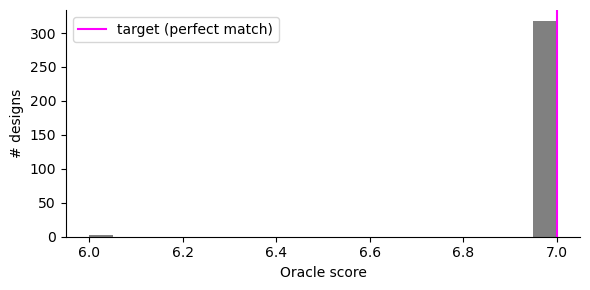

In [5]:
plt.figure(figsize=(6, 3))
plt.hist(scores.numpy(), bins=20, color="0.5")
plt.axvline(7, color="magenta", label="target (perfect match)")
plt.xlabel("Oracle score")
plt.ylabel("# designs")
plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Because every design is sampled from the *same* weight matrix, they are correlated — they are variations on one solution, not independent solutions — but they spread around the target value. This is exactly why drawing many samples is useful: you can generate a large pool quickly and then pick the individual designs you like best.

### Option 2: ask for the samples up front with `n_samples`

If you already know how many designs you want, the wrapper can draw them for you in the same call. Pass `n_samples` and Ledidi fits as usual and then samples that many sequences from the fitted weights before returning. This is the same fast sampling as above, just folded into one call.

In [6]:
X_hat = ledidi(model, X, y_bar, device="cpu", random_state=0,
	n_samples=1000, verbose=False)

X_hat.shape

torch.Size([1000, 4, 50])

We got 1000 designs back instead of the default `batch_size` of 16, and it took only marginally longer than the default run — almost all of the time is in the fitting, not the sampling.

### Option 3: build and fit the `Ledidi` object yourself

For full control you can skip the wrapper entirely. Construct a `Ledidi` object with the model and the `(n_channels, length)` shape of the sequence, call `fit_transform` to optimize the weights and return a batch of designs, and then call the object like a module to sample more. This is precisely what the wrapper does internally for a single run.

In [7]:
designer = Ledidi(model, shape=X.shape[-2:], random_state=0, verbose=False)

X_hat = designer.fit_transform(X, y_bar)   # fits the weights, returns a batch
more = designer(X)                          # samples another batch, no re-fitting

print("fit_transform returned:", tuple(X_hat.shape))
print("a follow-up sample:    ", tuple(more.shape))

fit_transform returned: (16, 4, 50)
a follow-up sample:     (16, 4, 50)


### Which should I use?

- Reach for the plain `ledidi(...)` wrapper for almost everything — it is the path the other tutorials take.
- Add `n_samples` when you simply want a large pool of designs from one fit.
- Keep the fitted object (`return_designer=True`, or build `Ledidi` directly) when you want to sample interactively, inspect the learned `designer.weights`, or otherwise reuse the fitted state across many calls without paying to re-fit.

For a given `random_state`, all three fit the *same* weight matrix and therefore draw from the same distribution of designs. They do not all return the same sequences, though: the plain wrapper returns the best batch found during fitting, while `n_samples` and repeated `designer(X)` calls draw fresh samples from that distribution.